# 03 Dataset EDA

Bu notebook, `final_labeled_dataset.csv` dosyası üzerinde Gün 4 veri analizi adımlarını uygular.

Amaçlar:
- eksik değerleri görmek
- label dağılımını incelemek
- protocol dağılımını incelemek
- packet length istatistiklerini görmek
- sınıflar arası temel farkları anlamak

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
DATASET_PATH = Path('../data/processed/final_labeled_dataset.csv')
df = pd.read_csv(DATASET_PATH, low_memory=False)
df.head()

,src_ip,dst_ip,src_port,dst_port,protocol,packet_length,time_delta,label
0,3.211.33.210,10.100.1.194,443,60815,TLS,85,0.000000,browsing
1,3.211.33.210,10.100.1.194,443,60815,TCP,56,0.000000,browsing
2,10.100.1.194,3.211.33.210,60815,443,TCP,54,0.000271,browsing
3,10.100.1.194,3.211.33.210,60815,443,TLS,85,0.001216,browsing
4,10.100.1.194,3.211.33.210,60815,443,TCP,54,0.000577,browsing


## 1. Dataset Boyutu

Önce veri setinin kaç satır ve kaç sütundan oluştuğuna bakalım.

In [3]:
print('Satır sayısı:', len(df))
print('Sütun sayısı:', len(df.columns))
print('Sütunlar:', list(df.columns))

Satır sayısı: 1019805
Sütun sayısı: 8
Sütunlar: ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'packet_length', 'time_delta', 'label']


## 2. Eksik Değerler

Eksik değer kontrolü, model eğitiminden önce yapılması gereken en temel adımdır.

In [4]:
missing_counts = df.isna().sum()
missing_counts

src_ip           0
dst_ip           0
src_port         0
dst_port         0
protocol         0
packet_length    0
time_delta       0
label            0
dtype: int64

Yorum:
- Eğer eksik değer çok fazlaysa, doldurma veya temizleme gerekir.
- Eğer eksik değer azsa, bazı satırlar kaldırılabilir.

## 3. Label Distribution

Bu adım veri dengesizliği var mı sorusuna cevap verir.

In [5]:
label_counts = df['label'].value_counts()
label_counts

label
download    916205
youtube      68479
browsing     35121
Name: count, dtype: int64

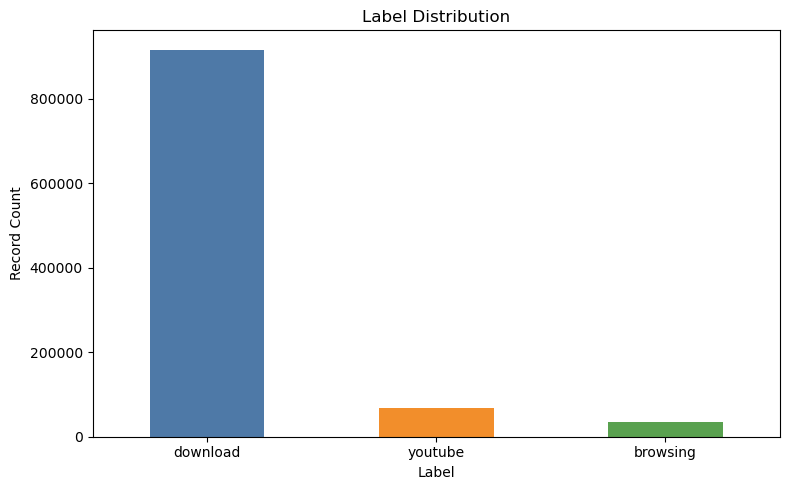

In [6]:
plt.figure(figsize=(8, 5))
label_counts.plot(kind='bar', color=['#4E79A7', '#F28E2B', '#59A14F'])
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Record Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Yorum:
- Eğer bir sınıf çok baskınsa buna veri dengesizliği denir.
- Veri dengesizliği model performansını etkileyebilir.

## 4. Protocol Distribution

Bu adım, veri setindeki baskın ağ protokollerini gösterir.

In [7]:
protocol_counts = df['protocol'].value_counts()
protocol_counts

protocol
TCP     786887
TLS     163268
QUIC     68568
DNS        969
UDP        113
Name: count, dtype: int64

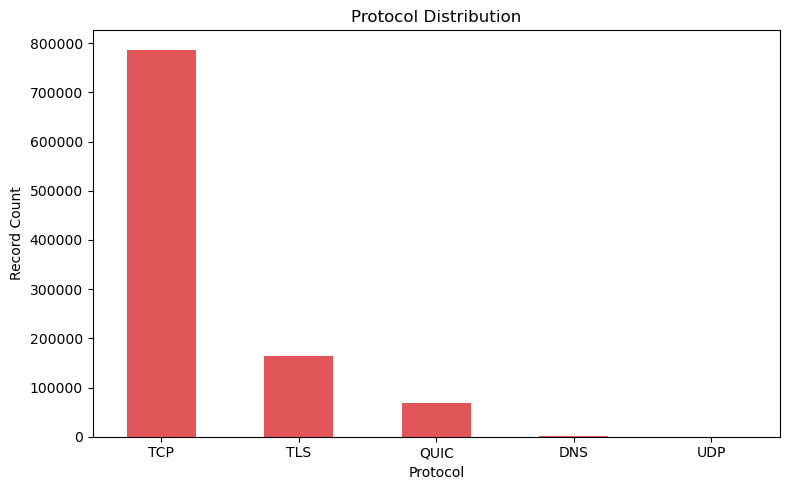

In [8]:
plt.figure(figsize=(8, 5))
protocol_counts.plot(kind='bar', color='#E15759')
plt.title('Protocol Distribution')
plt.xlabel('Protocol')
plt.ylabel('Record Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Yorum:
- YouTube tarafında QUIC ve UDP beklenir.
- Download tarafında TCP ve TLS baskın olabilir.
- Browsing tarafında TCP, DNS ve TLS birlikte görülebilir.

## 5. Packet Length Statistics

Paket boyutu ortalamaları trafik türlerini ayırmada faydalı olabilir.

In [9]:
df['packet_length'].describe()

count    1.019805e+06
mean     1.209214e+03
std      4.993527e+02
min      5.400000e+01
25%      1.436000e+03
50%      1.436000e+03
75%      1.436000e+03
max      1.436000e+03
Name: packet_length, dtype: float64

In [10]:
df.groupby('label')['packet_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
browsing,35121.0,818.269355,660.068602,54.0,56.0,1436.0,1436.0,1436.0
download,916205.0,1229.405544,492.266555,54.0,1436.0,1436.0,1436.0,1436.0
youtube,68479.0,1139.575549,398.895626,63.0,1292.0,1292.0,1292.0,1292.0


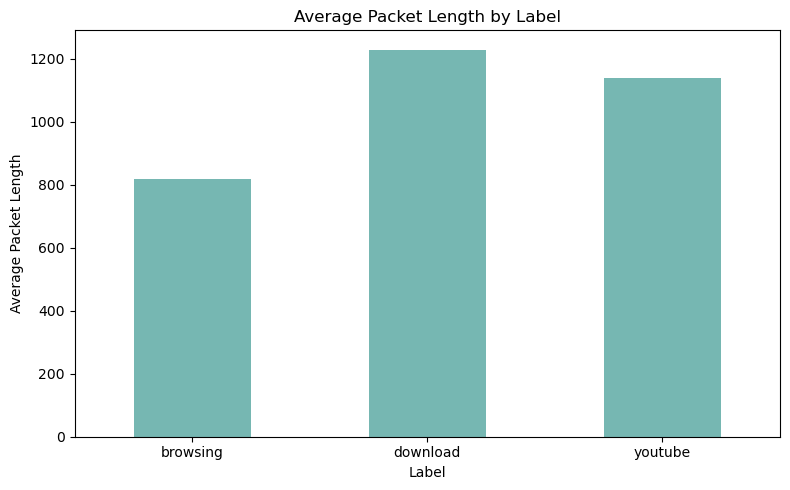

In [11]:
plt.figure(figsize=(8, 5))
df.groupby('label')['packet_length'].mean().plot(kind='bar', color='#76B7B2')
plt.title('Average Packet Length by Label')
plt.xlabel('Label')
plt.ylabel('Average Packet Length')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Yorum:
- Sınıflar arasında ortalama paket boyutu değişiyorsa bu feature yararlı olabilir.
- Büyük download trafiği ile kısa browsing paketleri farklı davranış gösterebilir.

## 6. Protocol ve Label Birlikte

Aynı protocol farklı sınıflarda farklı yoğunlukta olabilir.

In [12]:
protocol_by_label = pd.crosstab(df['label'], df['protocol'])
protocol_by_label

protocol,DNS,QUIC,TCP,TLS,UDP
label,,,,,
browsing,735,290,24803,9293,0
download,0,146,762084,153975,0
youtube,234,68132,0,0,113


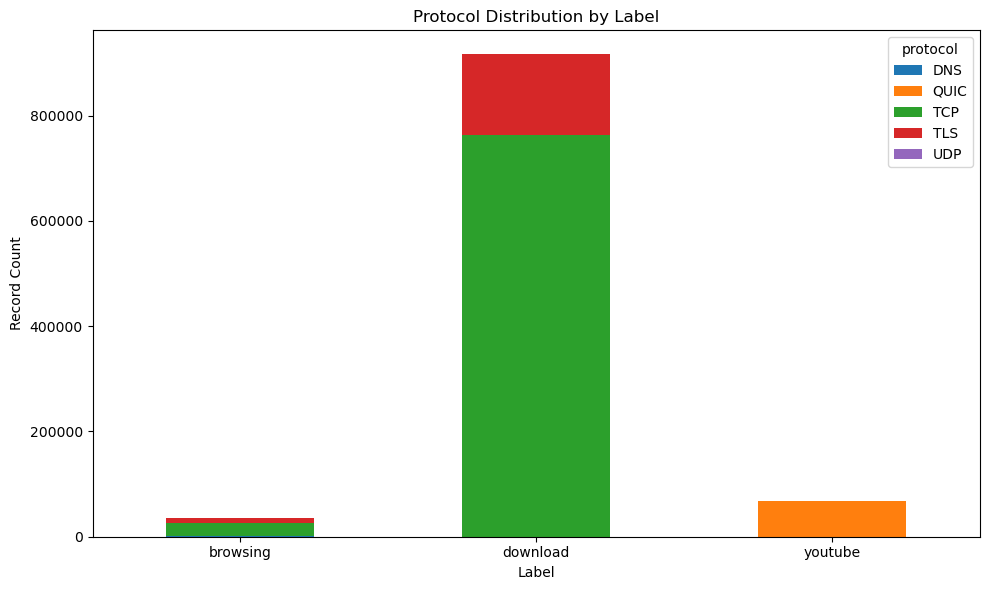

In [13]:
protocol_by_label.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Protocol Distribution by Label')
plt.xlabel('Label')
plt.ylabel('Record Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Yorum:
- Bu grafik, feature'ların sınıflar arasında nasıl değiştiğini daha net gösterir.
- ML modeli de zaten bu farkları öğrenmeye çalışır.

## 7. Basit Sonuçlar

Bu notebook sonunda şu sorulara cevap verebilmelisin:
- Veri dengeli mi?
- Hangi protocol daha baskın?
- Paket boyutları sınıflara göre değişiyor mu?
- Hangi feature'lar model için faydalı olabilir?